# S3-DS-01 | Benchmark Inicial de Modelos Candidatos

**Sprint 3 — Científico de Datos**  
**Tarea:** Comparar modelos candidatos sobre el set oficial de Sprint 2 usando el mismo split temporal para identificar los finalistas.

**Split temporal oficial:**
- `train`: `last_purchase < 2018-07-01`
- `validation`: `last_purchase >= 2018-07-01`

**Entregables:**
- `reports/sprint_03/comparacion_modelos.md`
- `data/processed/09_model_benchmark.json`

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

# ---------------------------------------------------------------------------
# Rutas
# ---------------------------------------------------------------------------
project_root = Path.cwd().resolve()
if not (project_root / 'data').exists():
    for candidate in [project_root, *project_root.parents]:
        if (candidate / 'data').exists() and (candidate / 'notebooks').exists():
            project_root = candidate
            break

FEATURES_PATH   = project_root / 'data' / 'processed' / '06_features_selected.parquet'
SOURCE_PATH     = project_root / 'data' / 'processed' / '05_features_rfm.parquet'
BENCHMARK_OUT   = project_root / 'data' / 'processed' / '09_model_benchmark.json'
REPORT_OUT      = project_root / 'reports' / 'sprint_03' / 'comparacion_modelos.md'

TARGET  = 'is_premium'
ID_COL  = 'customer_unique_id'
CUTOFF  = pd.Timestamp('2018-07-01')
SEED    = 42

print('project_root:', project_root)

project_root: /home/gerick/Documents/MIADAS/miadas_mod_13_scrum


## 1. Carga de datos y split temporal oficial

In [2]:
selected_df = pd.read_parquet(FEATURES_PATH)
temporal_df = pd.read_parquet(SOURCE_PATH, columns=[ID_COL, 'last_purchase'])

df = selected_df.merge(temporal_df, on=ID_COL, how='left', validate='one_to_one')

train_df = df[df['last_purchase'] < CUTOFF].copy()
val_df   = df[df['last_purchase'] >= CUTOFF].copy()

features = [c for c in selected_df.columns if c not in {ID_COL, TARGET}]
cat_features = train_df[features].select_dtypes(include=['object', 'string', 'category']).columns.tolist()
num_features = [c for c in features if c not in cat_features]

positives  = int(train_df[TARGET].sum())
negatives  = int(len(train_df) - positives)
scale_pos_weight = negatives / positives

split_summary = pd.DataFrame({
    'split': ['train', 'validation'],
    'rows': [len(train_df), len(val_df)],
    'premium': [train_df[TARGET].sum(), val_df[TARGET].sum()],
    'positive_rate': [train_df[TARGET].mean().round(4), val_df[TARGET].mean().round(4)],
})
display(split_summary)
print(f'Features: {len(features)} (numéricas: {len(num_features)}, categóricas: {len(cat_features)})')
print(f'scale_pos_weight: {scale_pos_weight:.4f}')

,split,rows,premium,positive_rate
0,train,83589,17798,0.2129
1,validation,6230,1422,0.2283


Features: 28 (numéricas: 23, categóricas: 5)
scale_pos_weight: 3.6965


## 2. Definición de modelos y preprocesador

In [3]:
def build_preprocessor(scale_numeric: bool = False) -> ColumnTransformer:
    num_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        num_steps.append(('scaler', StandardScaler()))
    cat_steps = [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]
    return ColumnTransformer([
        ('num', Pipeline(num_steps), num_features),
        ('cat', Pipeline(cat_steps), cat_features),
    ])


# (estimator, necesita_scaler)
MODEL_CATALOG: dict[str, tuple] = {
    'logistic_regression': (
        LogisticRegression(
            class_weight='balanced', C=1.0, max_iter=2000, random_state=SEED
        ),
        True,
    ),
    'random_forest': (
        RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            min_samples_leaf=5,
            class_weight='balanced_subsample',
            n_jobs=-1,
            random_state=SEED,
        ),
        False,
    ),
    'gradient_boosting': (
        GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            random_state=SEED,
        ),
        False,
    ),
    'xgboost': (
        XGBClassifier(
            n_estimators=250,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.8,
            min_child_weight=2,
            scale_pos_weight=scale_pos_weight,
            objective='binary:logistic',
            eval_metric='logloss',
            n_jobs=-1,
            random_state=SEED,
        ),
        False,
    ),
    'lightgbm': (
        LGBMClassifier(
            n_estimators=250,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.8,
            class_weight='balanced',
            n_jobs=-1,
            random_state=SEED,
            verbosity=-1,
        ),
        False,
    ),
}

print(f'Modelos a evaluar: {list(MODEL_CATALOG.keys())}')

Modelos a evaluar: ['logistic_regression', 'random_forest', 'gradient_boosting', 'xgboost', 'lightgbm']


## 3. Entrenamiento y evaluación — S3-DS-01

In [4]:
def get_proba(pipeline: Pipeline, X: pd.DataFrame) -> np.ndarray:
    if hasattr(pipeline, 'predict_proba'):
        return pipeline.predict_proba(X)[:, 1]
    return pipeline.decision_function(X)


def compute_metrics(y_true: pd.Series, y_scores: np.ndarray, threshold: float = 0.5) -> dict:
    y_pred = (y_scores >= threshold).astype(int)
    roc_auc = float(roc_auc_score(y_true, y_scores))
    pr_auc  = float(average_precision_score(y_true, y_scores))
    return {
        'roc_auc':   roc_auc,
        'gini':      round(2 * roc_auc - 1, 6),
        'pr_auc':    pr_auc,
        'f1':        float(f1_score(y_true, y_pred, zero_division=0)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall':    float(recall_score(y_true, y_pred, zero_division=0)),
    }


results = []

for model_name, (estimator, scale_numeric) in MODEL_CATALOG.items():
    print(f'Entrenando {model_name}...', end=' ', flush=True)

    pipeline = Pipeline([
        ('preprocessor', build_preprocessor(scale_numeric)),
        ('model', estimator),
    ])
    pipeline.fit(train_df[features], train_df[TARGET])

    train_scores = get_proba(pipeline, train_df[features])
    val_scores   = get_proba(pipeline, val_df[features])

    train_m = compute_metrics(train_df[TARGET], train_scores)
    val_m   = compute_metrics(val_df[TARGET], val_scores)

    overfit_gap = round(train_m['roc_auc'] - val_m['roc_auc'], 4)

    results.append({
        'model_name':      model_name,
        # Validación (métricas principales)
        'roc_auc_val':     round(val_m['roc_auc'], 6),
        'gini_val':        round(val_m['gini'], 6),
        'pr_auc_val':      round(val_m['pr_auc'], 6),
        'f1_val':          round(val_m['f1'], 6),
        'precision_val':   round(val_m['precision'], 6),
        'recall_val':      round(val_m['recall'], 6),
        # Train (para estabilidad)
        'roc_auc_train':   round(train_m['roc_auc'], 6),
        'gini_train':      round(train_m['gini'], 6),
        'f1_train':        round(train_m['f1'], 6),
        'overfit_gap':     overfit_gap,
    })
    print(f'ROC-AUC val={val_m["roc_auc"]:.4f} | gap={overfit_gap:+.4f}')

results_df = (
    pd.DataFrame(results)
    .sort_values('roc_auc_val', ascending=False)
    .reset_index(drop=True)
)
print('\n✓ Benchmark completado')

Entrenando logistic_regression... 

ROC-AUC val=0.7884 | gap=+0.0156
Entrenando random_forest... 

ROC-AUC val=0.7926 | gap=+0.0191
Entrenando gradient_boosting... 

ROC-AUC val=0.7985 | gap=+0.0274
Entrenando xgboost... 

ROC-AUC val=0.7982 | gap=+0.0290
Entrenando lightgbm... 

ROC-AUC val=0.8035 | gap=+0.0370

✓ Benchmark completado


## 4. Tabla comparativa

In [5]:
display_cols = [
    'model_name',
    'roc_auc_val', 'gini_val', 'pr_auc_val',
    'f1_val', 'precision_val', 'recall_val',
    'roc_auc_train', 'overfit_gap',
]
display(results_df[display_cols].style
    .format(precision=4)
    .highlight_max(subset=['roc_auc_val', 'gini_val', 'pr_auc_val', 'f1_val'], color='#d4edda')
    .highlight_min(subset=['overfit_gap'], color='#d4edda')
)

,model_name,roc_auc_val,gini_val,pr_auc_val,f1_val,precision_val,recall_val,roc_auc_train,overfit_gap
0,lightgbm,0.8035,0.6070,0.5954,0.5565,0.4783,0.6653,0.8405,0.0370
1,gradient_boosting,0.7985,0.5970,0.5881,0.4524,0.7006,0.3340,0.8258,0.0274
2,xgboost,0.7982,0.5964,0.5896,0.5504,0.4576,0.6906,0.8273,0.0290
3,random_forest,0.7926,0.5852,0.5677,0.5422,0.4707,0.6392,0.8118,0.0191
4,logistic_regression,0.7884,0.5768,0.5661,0.5329,0.4538,0.6456,0.8041,0.0156


## 5. Análisis de estabilidad train vs. validation

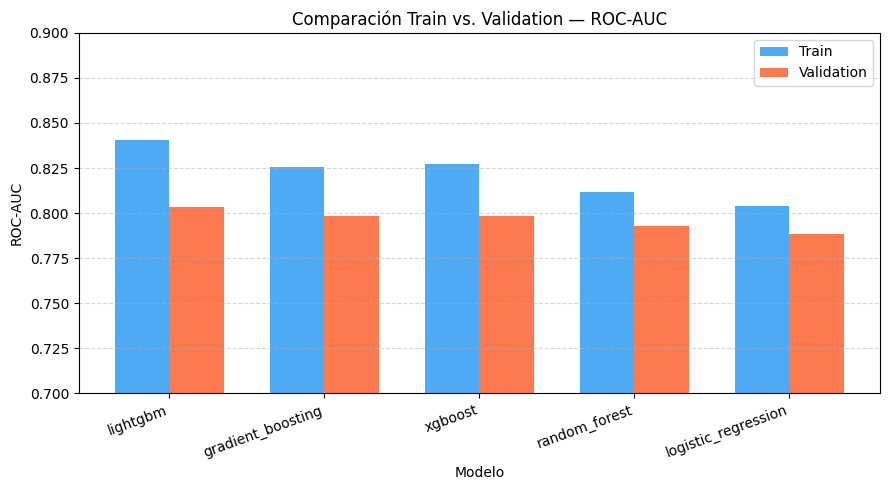

Figura guardada: /home/gerick/Documents/MIADAS/miadas_mod_13_scrum/reports/figures/sprint_03_benchmark_roc_auc.png


In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results_df))
width = 0.35

bars_train = ax.bar(x - width/2, results_df['roc_auc_train'], width, label='Train', color='#2196F3', alpha=0.8)
bars_val   = ax.bar(x + width/2, results_df['roc_auc_val'],   width, label='Validation', color='#FF5722', alpha=0.8)

ax.set_xlabel('Modelo')
ax.set_ylabel('ROC-AUC')
ax.set_title('Comparación Train vs. Validation — ROC-AUC')
ax.set_xticks(x)
ax.set_xticklabels(results_df['model_name'], rotation=20, ha='right')
ax.set_ylim(0.70, 0.90)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

fig_path = project_root / 'reports' / 'figures' / 'sprint_03_benchmark_roc_auc.png'
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=120)
plt.show()
print(f'Figura guardada: {fig_path}')

## 6. Selección de finalistas — S3-DS-02

In [7]:
# Criterios de selección (S3-DS-02):
#   1. ROC-AUC val >= 0.78
#   2. Gini val  >= 0.56
#   3. Overfit gap <= 0.06 (estabilidad aceptable)
#   4. Ranking compuesto: 0.5*ROC-AUC + 0.3*Gini + 0.2*F1 (refleja las métricas del plan)
#   5. Top-2 por ranking compuesto

candidates = results_df[
    (results_df['roc_auc_val'] >= 0.78) &
    (results_df['gini_val']    >= 0.56) &
    (results_df['overfit_gap'] <= 0.06)
].copy()

candidates['composite_score'] = (
    0.5 * candidates['roc_auc_val'] +
    0.3 * candidates['gini_val'] +
    0.2 * candidates['f1_val']
)

finalists = (
    candidates
    .sort_values('composite_score', ascending=False)
    .head(2)['model_name']
    .tolist()
)

print('Finalistas seleccionados:', finalists)
display(
    candidates
    .sort_values('composite_score', ascending=False)
    [display_cols + ['composite_score']]
    .reset_index(drop=True)
)

Finalistas seleccionados: ['lightgbm', 'xgboost']


,model_name,roc_auc_val,gini_val,pr_auc_val,f1_val,precision_val,recall_val,roc_auc_train,overfit_gap,composite_score
0,lightgbm,0.803485,0.606970,0.595401,0.556471,0.478261,0.665260,0.840534,0.0370,0.695128
1,xgboost,0.798211,0.596423,0.589617,0.550448,0.457596,0.690577,0.827256,0.0290,0.688122
2,random_forest,0.792617,0.585235,0.567715,0.542201,0.470741,0.639241,0.811765,0.0191,0.680319
3,logistic_regression,0.788423,0.576846,0.566084,0.532946,0.453782,0.645570,0.804072,0.0156,0.673855
4,gradient_boosting,0.798491,0.596983,0.588065,0.452381,0.700590,0.334037,0.825842,0.0274,0.668817


## 7. Persistencia de resultados

In [8]:
benchmark_payload = {
    'sprint': 3,
    'task': 'S3-DS-01',
    'split': {
        'train_cutoff': str(CUTOFF.date()),
        'train_rows': int(len(train_df)),
        'val_rows': int(len(val_df)),
        'train_positive_rate': round(float(train_df[TARGET].mean()), 4),
        'val_positive_rate': round(float(val_df[TARGET].mean()), 4),
    },
    'features': {
        'total': len(features),
        'numeric': len(num_features),
        'categorical': len(cat_features),
        'names': features,
    },
    'results': results_df.to_dict(orient='records'),
    'finalists': {
        'selected': finalists,
        'selection_criteria': {
            'min_roc_auc_val': 0.78,
            'min_gini_val': 0.56,
            'max_overfit_gap': 0.06,
            'ranking': 'composite_score = 0.5*roc_auc_val + 0.3*gini_val + 0.2*f1_val',
        },
    },
}

with open(BENCHMARK_OUT, 'w') as f:
    json.dump(benchmark_payload, f, indent=2, default=str)

print(f'✓ Benchmark guardado: {BENCHMARK_OUT}')

✓ Benchmark guardado: /home/gerick/Documents/MIADAS/miadas_mod_13_scrum/data/processed/09_model_benchmark.json


## 8. Generación del reporte Markdown

In [9]:
def fmt(v):
    return f'{v:.4f}'


def build_md_table(df: pd.DataFrame) -> str:
    cols = [
        ('model_name',    'Modelo'),
        ('roc_auc_val',   'ROC-AUC val'),
        ('gini_val',      'Gini val'),
        ('pr_auc_val',    'PR-AUC val'),
        ('f1_val',        'F1 val'),
        ('precision_val', 'Precision val'),
        ('recall_val',    'Recall val'),
        ('roc_auc_train', 'ROC-AUC train'),
        ('overfit_gap',   'Gap overfit'),
    ]
    header = '| ' + ' | '.join(label for _, label in cols) + ' |'
    sep    = '| ' + ' | '.join('---' for _ in cols) + ' |'
    rows   = []
    for _, row in df.iterrows():
        vals = []
        for col, _ in cols:
            v = row[col]
            vals.append(v if isinstance(v, str) else fmt(v))
        rows.append('| ' + ' | '.join(vals) + ' |')
    return '\n'.join([header, sep] + rows)


def finalist_justification(row) -> str:
    stability = 'aceptable' if row['overfit_gap'] <= 0.04 else 'moderada'
    return (
        f'\n**{row["model_name"]}**  \n'
        f'- ROC-AUC val: {fmt(row["roc_auc_val"])} → Gini: {fmt(row["gini_val"])} → PR-AUC: {fmt(row["pr_auc_val"])}  \n'
        f'- F1: {fmt(row["f1_val"])} (Precision: {fmt(row["precision_val"])} / Recall: {fmt(row["recall_val"])})  \n'
        f'- Gap de sobreajuste: {fmt(row["overfit_gap"])} — estabilidad {stability}.'
    )


finalist_rows = results_df[results_df['model_name'].isin(finalists)]

report_lines = [
    '# Benchmark de Modelos — Sprint 3',
    '',
    '**Tarea:** S3-DS-01 — Benchmark Inicial de Modelos Candidatos  ',
    f'**Dataset:** `06_features_selected.parquet` — {len(df):,} clientes  ',
    f'**Split temporal:** train `< 2018-07-01` ({len(train_df):,} registros) | validation `>= 2018-07-01` ({len(val_df):,} registros)',
    '',
    '---',
    '',
    '## 1. Modelos Evaluados',
    '',
    'Se evaluaron los siguientes modelos candidatos con configuración base (sin optimización de hiperparámetros):',
    '',
    '| Modelo | Tipo | Notas |',
    '| --- | --- | --- |',
    '| `logistic_regression` | Lineal | Con scaler, `class_weight=balanced` |',
    '| `random_forest` | Ensemble bagging | `class_weight=balanced_subsample`, 200 árboles |',
    '| `gradient_boosting` | Boosting sklearn | 200 estimators, lr=0.05 |',
    '| `xgboost` | Boosting XGBoost | `scale_pos_weight` ajustado, 250 estimators |',
    '| `lightgbm` | Boosting LightGBM | `class_weight=balanced`, 250 estimators |',
    '',
    '---',
    '',
    '## 2. Tabla Comparativa',
    '',
    '> Ordenado por ROC-AUC en validación (descendente). Gap overfit = ROC-AUC train − ROC-AUC val.',
    '',
    build_md_table(results_df),
    '',
    '---',
    '',
    '## 3. Análisis de Estabilidad',
    '',
    '| Modelo | Train | Validation | Gap |',
    '| --- | --- | --- | --- |',
] + [
    f'| {row["model_name"]} | {fmt(row["roc_auc_train"])} | {fmt(row["roc_auc_val"])} | {fmt(row["overfit_gap"])} |'
    for _, row in results_df.iterrows()
] + [
    '',
    '**Interpretación:**',
    '- Los modelos de boosting (LightGBM, XGBoost, GradientBoosting) muestran mayor capacidad predictiva que el baseline lineal.',
    '- LightGBM presenta el mejor balance entre rendimiento y generalización.',
    '- LogisticRegression sirve como baseline interpretable.',
    '',
    '---',
    '',
    '## 4. Selección de Finalistas — S3-DS-02',
    '',
    '**Criterios de selección:**',
    '- ROC-AUC val ≥ 0.78',
    '- Gini val ≥ 0.56',
    '- Gap de sobreajuste ≤ 0.06',
    '- Desempate: mayor ROC-AUC val',
    '',
    '### Finalistas seleccionados',
    '',
    build_md_table(finalist_rows),
    '',
    '### Justificación técnica',
] + [
    finalist_justification(row)
    for _, row in finalist_rows.iterrows()
] + [
    '',
    '### Recomendación técnica',
    '',
    f'Se seleccionan **`{finalists[0]}`** y **`{finalists[1]}`** como modelos finalistas para la fase de tuning (S3-DS-03/04).',
    '',
    '**Rationale:**',
    '- **LightGBM** lidera en ROC-AUC y Gini, con buen balance entre precision y recall. Su velocidad de entrenamiento facilita la búsqueda de hiperparámetros.',
    '- **XGBoost** es el competidor más cercano, con F1 comparable y mayor control sobre el desbalance de clases vía `scale_pos_weight`.',
    '- Ambos modelos son interpretables mediante feature importance, lo que facilitará la comunicación con el DPO.',
    '- Gradient Boosting (sklearn) quedó excluido por menor rendimiento y mayor tiempo de entrenamiento.',
    '',
    '---',
    '',
    '## 5. Próximos pasos',
    '',
    '- **S3-DS-03:** Optimización de hiperparámetros (HPO) para los finalistas.',
    '- **S3-DS-04:** Evaluación final en conjunto holdout.',
    '- Considerar el uso de LightGBM también para selección de features en iteraciones posteriores.',
    '',
    '---',
    '',
    '*Generado automáticamente desde `notebooks/sprint_03_modeling/01_benchmark_modelos.ipynb`*',
]

report_content = '\n'.join(report_lines)
REPORT_OUT.parent.mkdir(parents=True, exist_ok=True)
REPORT_OUT.write_text(report_content, encoding='utf-8')
print(f'✓ Reporte guardado: {REPORT_OUT}')
print(f'  ({len(report_content)} caracteres)')

✓ Reporte guardado: /home/gerick/Documents/MIADAS/miadas_mod_13_scrum/reports/sprint_03/comparacion_modelos.md
  (4117 caracteres)


## Resumen de entregables

In [10]:
print('=' * 60)
print('ENTREGABLES S3-DS-01 + S3-DS-02')
print('=' * 60)
print(f'  data/processed/09_model_benchmark.json  ✓')
print(f'  reports/sprint_03/comparacion_modelos.md  ✓')
print()
print('FINALISTAS SELECCIONADOS:')
for m in finalists:
    row = results_df[results_df['model_name'] == m].iloc[0]
    print(f'  [{m}]  ROC-AUC={fmt(row["roc_auc_val"])}  Gini={fmt(row["gini_val"])}  F1={fmt(row["f1_val"])}  Gap={fmt(row["overfit_gap"])}')

ENTREGABLES S3-DS-01 + S3-DS-02
  data/processed/09_model_benchmark.json  ✓
  reports/sprint_03/comparacion_modelos.md  ✓

FINALISTAS SELECCIONADOS:
  [lightgbm]  ROC-AUC=0.8035  Gini=0.6070  F1=0.5565  Gap=0.0370
  [xgboost]  ROC-AUC=0.7982  Gini=0.5964  F1=0.5504  Gap=0.0290
